### FAIRNESS - PROJET FINAL




In [1]:
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
! python -m pip install numpy fairlearn plotly nbformat ipykernel aif360["inFairness"] aif360['AdversarialDebiasing'] causal-learn BlackBoxAuditing cvxpy dice-ml lime shapkit

# **INTRODUCTION**


La radiographie thoracique est l'un des examens d'imagerie médicale les plus fréquents et les plus coûtants. Pour limiter ces coûts, il serait intéressant d'avoir système de détection et de diagnostic assisté par ordinateur (DAO). Cependant, pour avoir un système pertinent, il faut s'assurer que le jeu de données sur lequel on l'entraîne soit sans biais car l'IA a tendance à renforcer les biais déjà présents et limiter les biais à la sortie du modèle. On va donc étudier le jeu de données à disposition afin de mettre les différents biais possiblement présents en lumière. Nous allons ensuite tenir compte de ces biais afin d'adapter le jeu de données avec des méthodes de pré-processing et étudier les effets sur les prédictions du modèles et les améliorer avec des méthodes de post-processing afin d'obtenir des prédictions plus fiables.

**a -Description des données**
Le jeu de données du projet est le suivant :
NIH Chest X-ray Dataset of 14 Common Thorax Disease Categories: (1, Atelectasis; 2, Cardiomegaly; 3, Effusion; 4, Infiltration; 5, Mass; 6, Nodule; 7, Pneumonia; 8, Pneumothorax; 9, Consolidation; 10, Edema; 11, Emphysema; 12, Fibrosis; 13, Pleural_Thickening; 14 Hernia)

Ce jeu de données est un dataset d’image de rayons X, fourni avec de nombreuses informations sur les personnes (notamment age, genre, maladies). Le jeu de données a ces labels


---


Le jeu de données contient les informations cliniques et techniques suivantes pour chaque radiographie :

| Colonne | Description | Type | Rôle dans l'analyse |
| :--- | :--- | :--- | :--- |
| **Image Index** | Identifiant unique du fichier image (ex: `00000001_000.png`). | String | ID Image |
| **Finding Labels** | Les pathologies identifiées par les radiologues (ex: `Cardiomegaly`, `Effusion`). La valeur `No Finding` indique un patient sain. | String | **Variable Cible (Target)** |
| **Follow-up #** | Numéro de suivi de la visite. `0` indique la première visite, `1` la deuxième, etc. | Entier | Temporel / Historique |
| **Patient ID** | Identifiant unique du patient. Permet de regrouper plusieurs images d'une même personne. | Entier | ID Patient |
| **Patient Age** | Âge du patient au moment de l'examen (en années). | Entier | Variable Démographique |
| **Patient Gender** | Sexe du patient (`M` ou `F`). | String | **Variable Protégée (Biais)** |
| **View Position** | Position du patient lors de la radio : <br>- `PA` (Posteroanterior) : Rayon de dos (Patient debout/valide).<br>- `AP` (Anteroposterior) : Rayon de face (Patient souvent alité/complexe). | String | Variable Technique (Biais potentiel) |
| **OriginalImage[Width / Height]** | Largeur et Hauteur de l'image originale en pixels. | Entier | Méta-donnée image |
| **OriginalImagePixelSpacing[x / y]** | Résolution spatiale de l'image (taille physique d'un pixel en mm). | Float | Méta-donnée image |
| **Unnamed: 11** | Colonne vide ou résiduelle issue de l'importation du CSV (souvent due à une virgule traînante). | NaN / String | À ignorer ou à supprimer lors du nettoyage. |
| **train_valid** | Indique si l'image appartient au groupe d'entraînement (train) ou de validation (valid). | String | Partitionnement : Détermine l'usage de la donnée par le modèle. |
| **label** | Traduction simplifiée de Finding Labels en format binaire ou catégoriel (ex: 0 pour Sain, 1 pour Malade). | Entier | Variable Cible (Target) : Ce que le ResNet18 doit apprendre à prédire. |
| **weights** | Valeur numérique attribuée à chaque ligne pour l'entraînement. | Float | Pondération (Pre-processing) : Sert à corriger les déséquilibres et les biais de fairnes |

**b - Remarque** :
Le fait que plusieurs images soit pour le même patient présente un danger de biais considérable. En effet, un patient peut être à 5 reprises détecté pour la même maladie ce qui pèse dans le jeu de données et les images ne sont plus indépendantes.

**c - Plan** :

1.   Préparation de la donnée
2.   Analyse Descriptive et observation des biais
3. Première étude du modèle sur les données sans poids                           
  A- Analyse de la fairnesse du premier modèle                                    
  B- Méthodes de post-processing afin d'améliorer la fairness  
4. Mitigation des biais par pré-processing et études des modèles                  
  A- Méthode de Reweighting, analyse de la fairness, méthodes de post-processing                                                                
  B- Méthode de **Disparate Impact Remover**, analyse de la fairness, méthodes de post-processing
5.  Conclusion



---



# **1. Préparation de la donnée**

In [3]:
import pandas as pd
import numpy as np

In [14]:
import pandas as pd
#df = pd.read_csv(r'C:\Users\nadia\Downloads\Lesage_Margot\metadata.csv', sep=',')
df = pd.read_csv(r'metadata.csv', sep=',')

In [15]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,0.171,NaN,train,sain,1
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,0.171,NaN,train,sain,1
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,0.171,NaN,train,sain,1
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,0.143,NaN,train,sain,1


In [16]:
df.dtypes

,0
Image Index,object
Finding Labels,object
Follow-up #,int64
Patient ID,int64
Patient Age,int64
Patient Gender,object
View Position,object
OriginalImage[Width,int64
Height],int64
OriginalImagePixelSpacing[x,float64



Comme on avait pu le voir dans le mi -projet, les données contiennent des erreurs qu'il faut nettoyer   :

1.  **Filtrage des aberrances :** Supprimer les patients dont l'âge est supérieur à 100 ans (erreurs de saisie probables qui fausseraient les moyennes).
3.  **Encodage des variables d'intérêt :** On transforme les variables en valeurs binaires pour les rendres compatibles avec les algorithmes de pré et post processing

In [17]:
# Check that there is not NaN values
for column in df.columns:
  print(column, df[column].isnull().values.any())

Image Index False
Finding Labels False
Follow-up # False
Patient ID False
Patient Age False
Patient Gender False
View Position False
OriginalImage[Width False
Height] False
OriginalImagePixelSpacing[x False
y] False
Unnamed: 11 True
train_valid False
label False
WEIGHTS False


On selectionne des colonnes pour analyser les biais inhérents au jeu de données, on garde donc les informations autres que les images : la prise de vue (car une prise de vue allongée ou debut dépend en partie de la capacité de la personne étudiée à tenir debout), l'âge, le genre.
On veut pouvoir analyser les données donc on les met en format binaire.

In [18]:
# Sélection des colonnes
features_to_keep = ['Patient ID', 'Patient Age', 'Patient Gender','View Position', 'label', 'WEIGHTS']
df_pro = df[features_to_keep].copy()



# 1. Label : 1 = Sain (Favorable), 0 = Malade
df_pro['label'] = df_pro['label'].apply(lambda x: 1 if x == 'sain' else 0)

# 2. Genre : 1 = Homme (Privilégié), 0 = Femme
df_pro['Patient Gender'] = df_pro['Patient Gender'].map({'M': 1, 'F': 0})



df_pro["View Position"] = df_pro["View Position"].map({'AP': 1, 'PA': 0})
#Pour l'âge on va voir en fonction de si la personne est âgée (selon l'OMS à partir de 60 ans)
df_pro['est_âgée'] = (df_pro['Patient Age'] >= 60).astype(int)


display(df_pro.head())

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée
0,94,63,1,0,1,1,1
1,108,42,0,0,1,1,0
2,108,42,0,1,1,1,0
3,141,31,1,0,1,1,0
4,169,73,1,0,1,1,1


In [19]:
print(df_pro['Patient Age'].min())
print(df_pro['Patient Age'].max())

2
149


Comme on l'avait déjà étudié dans le mi-projet, l'âge contient des valeurs aberrantes qu'on va chercher à supprimer si le patient ne possède pas d'autre image ou remplacer si le patient a d'autres images avec un vrai âge indiqué.

In [20]:
erreurs = df_pro[df_pro['Patient Age'] > 105]
print(len(erreurs))

1


In [21]:
for index, err in erreurs.iterrows():
  print('voici les lignes pour ce patient')
  print(df_pro[df_pro['Patient ID'] == err['Patient ID']])

voici les lignes pour ce patient
      Patient ID  Patient Age  Patient Gender  View Position  label  WEIGHTS  \
2707       15558          149               1              0      1        1   
2708       15558           46               1              0      1        1   
2709       15558           46               1              0      0        1   
2710       15558           46               1              0      1        1   

      est_âgée  
2707         1  
2708         0  
2709         0  
2710         0  


In [22]:
df_pro.loc[df_pro['Patient Age'] == 149,'Patient Age'] = 46
df.loc[df['Patient Age'] == 149,'Patient Age'] = 46

In [23]:
#on vérifie qu'elles sont plus dans les âges aberrants
erreurs = df_pro[df_pro['Patient Age'] > 105]
erreurs

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée


Maintenant que notre jeu de données est nettoyé, on va en étudier les biais potentiels et chercher à savoir quels sont les paramètres induisant le plus de biais.



---

# **2. Analyse Descriptive et observation des biais**

/tmp/ipykernel_27111/1561022170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_pro, ax=axes[0], palette='pastel')
/tmp/ipykernel_27111/1561022170.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Patient Gender', data=df_pro, ax=axes[1], palette='Set2') # On utilise df original pour avoir 'M'/'F'


Text(0.5, 1.0, 'Distribution du Genre')

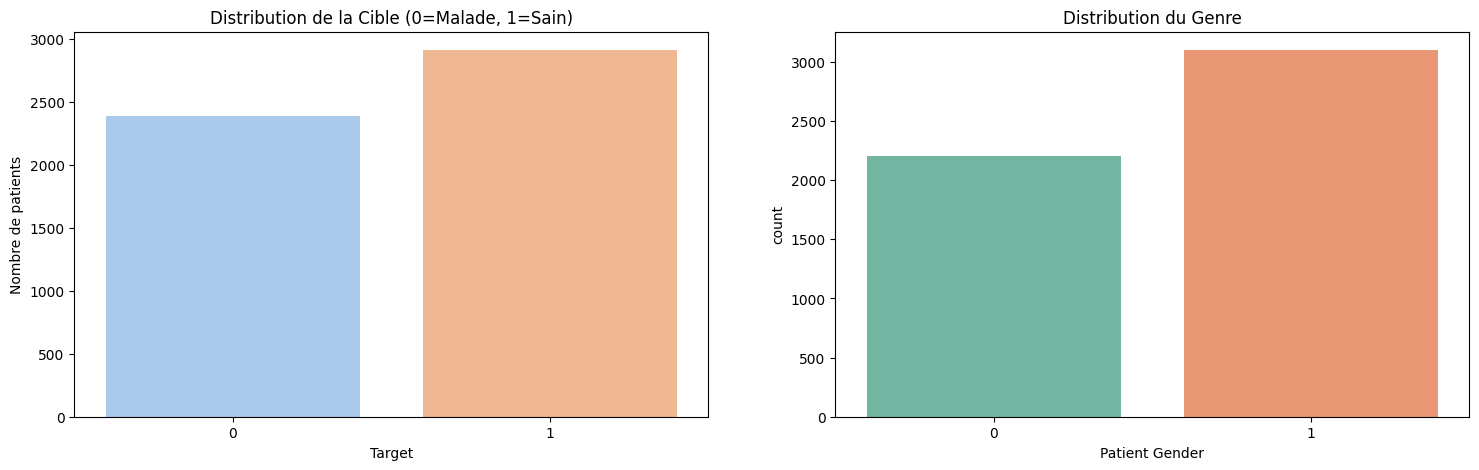

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Distribution des diagnostics (Sain vs Malade)
sns.countplot(x='label', data=df_pro, ax=axes[0], palette='pastel')
axes[0].set_title('Distribution de la Cible (0=Malade, 1=Sain)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Nombre de patients')

# 2. Distribution du Genre
sns.countplot(x='Patient Gender', data=df_pro, ax=axes[1], palette='Set2') # On utilise df original pour avoir 'M'/'F'
axes[1].set_title('Distribution du Genre')

Ce graphe nous permet déjà d'observer que les femmes sont sous représentées dans ce jeu de données, ce qui peut induire un biais de représentation et des erreurs dans le modèle.
On va maintenant observer sur un graphique les différences de proportion de femmes et hommes, personnes âgées ou non, Pa ou AP, malades.

In [25]:
import plotly.express as px

def Display_categorical_hist(df, cat_feature, target, color_sequence=None):
    df_temp = df.copy()
    df_temp[target] = df_temp[target].astype(str)
    fig = px.histogram(df_temp, x=cat_feature, color=target, barmode='group',
                       title=f"Nombre de cas : {target} par {cat_feature}",
                       labels={cat_feature: "Catégorie", "count": "Nombre de patients"},
                       color_discrete_sequence=color_sequence) # Pass the sequence here
    fig.show()

#celui en pourcentage
def Display_categorical_hist_percent(df, cat_feature, target, color_sequence=None):
    df_temp = df.copy()
    df_temp[target] = df_temp[target].astype(str)
    counts = df_temp.groupby([cat_feature, target])['Patient ID'].count().reset_index(name='count')

    total_by_cat = df_temp.groupby(cat_feature)['Patient ID'].count().reset_index(name='total')

    merged = pd.merge(counts, total_by_cat, on=cat_feature)
    merged['percentage'] = (merged['count'] / merged['total']) * 100

    fig = px.bar(merged, x=cat_feature, y='percentage', color=target, barmode='group',
                 title=f"Pourcentage de malades (0-malade, 1-sain) par {cat_feature}",
                 text=merged['percentage'].apply(lambda x: '{0:1.1f}%'.format(x)),
                 color_discrete_sequence=color_sequence) # Pass the sequence here

    fig.update_layout(yaxis_title="Pourcentage (%)")
    fig.show()

In [26]:
Display_categorical_hist_percent(df_pro, "View Position", 'label', color_sequence=['#FFC0CB', '#ADD8E6']) # Pink and Light Blue pastel duo
Display_categorical_hist_percent(df_pro, "Patient Gender", 'label', color_sequence=['#B3E5BE', '#FFFACD']) # Soft Pastel Green and Lemon Chiffon pastel duo
Display_categorical_hist_percent(df_pro, "est_âgée", 'label', color_sequence=['#F0F8FF', '#B0E0E6']) # AliceBlue and PowderBlue pastel duo

On voit sur ces graphiques que c'est au niveau de la prise de position que nous avons la plus grande différence de proportion de prise de position pour une personne saine ou malade.

On va étudier les variables de fairness afin de voir plus concrètement ces biais.

In [27]:
!pip install aif360

In [28]:
# Code to compute fairness metrics using aif360

from aif360.sklearn.metrics import *
from sklearn.metrics import  balanced_accuracy_score


# This method takes lists
def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics

#On analyse d'abord les biais inhérents à notre jeu de donnée tel quel par rapport être malade ou sain:
metrics_baseline_genre = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['Patient Gender'],
    priv_group=1 # On définit le groupe privilégié comme étant les hommes dans ce cas
)

metrics_baseline_position = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['View Position'],
    priv_group=1 # On définit le groupe privilégié comme étant ceux avec PA
)

metrics_baseline_age = get_metrics(
    y_true=df_pro['label'].values,
    y_pred=df_pro['label'].values,
    prot_attr=df_pro['est_âgée'],
    priv_group=1 # On définit le groupe privilégié comme étant plus de 60
)

In [29]:
# Code to compute fairness metrics using aif360

from aif360.sklearn.metrics import *
from sklearn.metrics import  balanced_accuracy_score


# This method takes lists
def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics

In [30]:
print( f"les résultats pour le genre sont {metrics_baseline_genre}")
print( f"les résultats pour la position sont {metrics_baseline_position}")
print(f"les résultats pour l'âge sont {metrics_baseline_age}")

les résultats pour le genre sont {'base_rate_truth': np.float64(0.5491046182846371), 'statistical_parity_difference': np.float64(0.0032784726793942953), 'disparate_impact_ratio': 1.005985433042475, 'base_rate_preds': np.float64(0.5491046182846371), 'equal_opportunity_difference': 0.0, 'average_odds_difference': 0.0, 'conditional_demographic_disparity': np.float64(0.0005425975690116422), 'smoothed_edf': np.float64(0.007258051971244295), 'df_bias_amplification': np.float64(0.0), 'balanced_accuracy_score': np.float64(1.0)}
les résultats pour la position sont {'base_rate_truth': np.float64(0.5491046182846371), 'statistical_parity_difference': np.float64(0.10396956982288247), 'disparate_impact_ratio': 1.2147267903181396, 'base_rate_preds': np.float64(0.5491046182846371), 'equal_opportunity_difference': 0.0, 'average_odds_difference': 0.0, 'conditional_demographic_disparity': np.float64(-0.024488468268506147), 'smoothed_edf': np.float64(0.22502482072273067), 'df_bias_amplification': np.float

Les résultats de la fonction get_metrics donnent de manière générique les variables suivantes :

base_rate_truth: La proportion de valeurs positives (être sain) dans le jeu de données en général.

statistical_parity_difference: Mesure de la différence d'être sain en fonction des groupes privilégiés et non privilégié. Si le jeu de donnée n'est pas biaisé, cette valeur doit être nulle. Si > 0 alors le groupe privilégié a plus de chances d'être sain.

disparate_impact_ratio: Le ratio de être sain entre les groupes non-privilégiés et privilégiés. Cette valeur doit tourner autour de 1, si elle est trop supérieure à 1, le groupe non privilégié a plus de chance d'être sain.

base_rate_preds: La proportion de valeurs être sain prédits pas le modèle (dans ce cas, c'est comme avant car on n'a pas fait de modèle, c'est le même jeu de données)

equal_opportunity_difference: Mesure la différence de vrais positifs entre les deux groupes. Le mieux est 0. Comme il n'y a pas de modèle dans ce cas, on obtientra 0.

average_odds_difference: On considère les taux de Faux Positifs et Vrais positifs, on veut avoir 0 (pareil on aura 0 dans ce cas car il n'y a pas de modèle)

conditional_demographic_disparity : Mesure la disparité entre les groupes en tenant compte de conditions ou de variables de contrôle spécifiques.

smoothed_edf : Une mesure de l'équité globale basée sur les différences de performance prédictive entre les groupes (généralement utilisée pour évaluer si les probabilités de prédiction sont distribuées de manière similaire).

df_bias_amplification : Indique à quel point le biais présent dans les données brutes risque d'être accentué (amplifié) par un modèle prédictif.

balanced_accuracy_score : La moyenne de la sensibilité (taux de vrais positifs) et de la spécificité (taux de vrais négatifs). On aura 1 ici comme il n'y a pas de modèle.

**ANALYSE DES RESULTATS DANS LE CAS PRESENT** :

Pour le genre : on a un statistical_parity_difference positif mais très proche de 0, de même le disparate_impact_ratio est très proche de 1. On peut donc soupçonner un biais mais très léger, il y a globalement la même proportion de Femmes et d'Hommes sains. C'est ce qu'on avait pu voir dans l'analyse descriptive.

Pour la position de vue : Le statistical-parity_difference est de 0,11 ce qui est plus grand que 0, de même, le disparate_impact_ratio est de 1,23 donc plus grand que 1, on observe donc un biais mesurable entre les groupes PA et AP. Le groupe privilégié, ici Pa a plus de chances d'être vu comme sain.

Pour l'âge :
Le statistical_parity_difference positif mais plutôt proche de 0 (0,06), de même le disparate_impact_ratio est à 1,13. Ainsi on peut trouver un biais pour l'âge, plus modéré que pour la prise de position mais existant néanmoins. Ainsi, les patients moins âgés ont plus de chance d'être vus comme sains que les autres.



---

# **3. Première étude du modèle sur les données sans poids**

On va maintenant étudier les manières de régler les problèmes de biais et les effets des biais sur les performances et biais du modèle de prédiction, dans un premier temps, on se concentre sur le jeu de données tel quel, c'est-à-dire pour lequel les biais montrés sont toujours présents. On fait tourner le modèle pour avoir les valeurs de prédiction dessus puis on observe si le modèle a renforcé les biais (partie A) et ensuite on essaie d'améliorer la fairness en utilisant des méthodes de post-processing (Partie B)

### **3.A - Analyse de la fairnesse du premier modèle**


In [31]:
#on télécharge le csv de prédiction afin de l'analyser et de voir s'il a renforcé les biais ou non
import pandas as pd
dfpredbase = pd.read_csv("predsbase.csv")
dfbase = pd.read_csv("metadata.csv")

In [32]:
dfpredbase.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS,preds,labels,preds_logit0,preds_logit1
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1,malade,sain,-0.096669,-0.868567
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,0.171,NaN,train,sain,1,sain,sain,-0.658153,-0.091075
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,0.171,NaN,train,sain,1,sain,sain,-1.169462,0.100732
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,0.171,NaN,train,sain,1,sain,sain,-0.916072,-0.291584
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,0.143,NaN,train,sain,1,sain,sain,-1.204708,-0.330240


In [33]:
import numpy as np

# on trie les lignes en ne gardant que celles de validations, celles sur lesquelles le fichier a été tourné
df_val = dfpredbase[dfpredbase['train_valid'] == 'valid'].copy()

#on convertit la valeur de labels en binaire
y_true = (df_val['labels'] == 'malade').astype(int)
y_pred = (df_val['preds'] == 'malade').astype(int)

# On regarde par rapport à la prise de position comme atrribut sensible car c'est lui
#qu'on va essayer de régler car le plus marqué comme on l'a vu dans l'analyse descriptive
prot_attr = (df_val['View Position'] == 'PA').astype(int)

# ici les poids ne sont que des 1
poids = df_val['WEIGHTS']

metriques = get_metrics(
    y_true=y_true,
    y_pred=y_pred,
    prot_attr=prot_attr,
    priv_group=1,    # 1 correspond à
    pos_label=1,     # 1 correspond à malade
    sample_weight=poids
)

# on affiche les résultats
for nom, valeur in metriques.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.25326748602610677
disparate_impact_ratio : 1.7318619169152978
base_rate_preds : 0.45305832147937414
equal_opportunity_difference : 0.25915039222466923
average_odds_difference : 0.2237806117592913
conditional_demographic_disparity : 0.0386658279830743
smoothed_edf : 0.5483714962767865
df_bias_amplification : 0.2512623179003268
balanced_accuracy_score : 0.6207641354502252


Comme on peut le voir, le modèle de prédiction a une réussite de 0,6 ce qui n'est pas terrible mais passable, cependant, il reproduit et renforce les biais, avec un disparate impact ratio de 1,73, on peut voir que le groupe privilégié, PA, a 1,7 fois plus de chances d'être diagnostiqué malade que ceux ayant AP. Les autres valeurs confirment ce résultat. On peut voir de plus que le modèle a fortement renforcé les biais avec un score de 0,25 > 0.

### **B- Méthodes de post-processing afin d'améliorer la fairness**

Le modèle a donc renfocé les biais, pour les traiter, nous allons tenter deux méthodes de post processing :
- Reject Option Classifier : cette méthode se concentre sur les individus pour lesquels le modèle est incertain et va forcer une décision (favorable si l'individu appartient au groupe non privilégié, et non favorable pour l'inverse)
- Calibrated Equalized-odds Post-Processing : permet d'équilibrer les taux de faux-négatif (ou catégorie entrée) tout en tenant compte des désiquilibres dans le jeu de donnée en terme de représentation des catégories.

In [34]:
#on va maintenant appliquer des méthodes de post processing, pour cela,
#nous devons créer un objet de la classe standart datatset pour lui appliquer les mesures de fairness

from aif360.datasets import StandardDataset
from aif360.algorithms.postprocessing.reject_option_classification import RejectOptionClassification

#on met les colonnes étudiées en binaire
df_val["label_maladie"] = (df_val["labels"] == "malade").astype(int)
df_val["Positionbin"] = (df_val["View Position"] == "PA").astype(int)

# On calcule la probabilité exacte (le Softmax)
df_val["scores_probabilite"] = np.exp(df_val["preds_logit1"]) / (np.exp(df_val["preds_logit0"]) + np.exp(df_val["preds_logit1"]))

dataset_orig_val = StandardDataset(
    df=df_val,
    label_name="label_maladie",
    favorable_classes=[1],
    protected_attribute_names=["Positionbin"],
    privileged_classes=[[1]],
    instance_weights_name="WEIGHTS",
    categorical_features=[],
    features_to_keep=["scores_probabilite"],
    features_to_drop=[],
    na_values=["?", "Unknown/Invalid"],
    custom_preprocessing=None,
    metadata=None,
)

In [35]:
#pour appliquer la méthode de post processing on doit recréer le df
#avec le taux de probabilité de certitude car cette méthode de post processing (Reject Option Classification)
#s'occupe d'adapter la décision en fonction de ces taux

df_val_pred = dataset_orig_val.copy(deepcopy=True)

# On injecte nos probabilités dans l'objet aif360
df_val_pred.scores = df_val["scores_probabilite"].values.reshape(-1, 1)

In [36]:
#on applique la fonction de fairness réalisant Reject option classification

metric_name = "Statistical parity difference"
metric_ub = 0.05
metric_lb = -0.05

ROC = RejectOptionClassification(
    unprivileged_groups= [{"Positionbin": 0}],
    privileged_groups=[{"Positionbin": 1}],
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name=metric_name,
    metric_ub=metric_ub,
    metric_lb=metric_lb,
)

ROC = ROC.fit(dataset_orig_val, df_val_pred)

In [37]:
print(f"Optimal classification threshold (with fairness constraints) = {ROC.classification_threshold:.4f}")
print(f"Optimal ROC margin = {ROC.ROC_margin:.4f}")

Optimal classification threshold (with fairness constraints) = 0.0892
Optimal ROC margin = 0.0018


Le seuil de décision est très bas, car le jeu de données est très biaisé.

In [38]:
df_roc_val_pred = ROC.predict(df_val_pred)

metriques_post_processing = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_roc_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

# Affichage des résultats
for nom, valeur in metriques_post_processing.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : -0.00640642882022191
disparate_impact_ratio : 0.9935698143361926
base_rate_preds : 0.9935988620199147
equal_opportunity_difference : -9.100340352719005e-05
average_odds_difference : -0.006546646408481839
conditional_demographic_disparity : -0.03810576956039042
smoothed_edf : 0.9312089124083887
df_bias_amplification : 0.634099734031929
balanced_accuracy_score : 0.5003481462985857


On voit ici assez clairement que le modèle a bien réussi à cooriger les biais, il n'en a plus ou preque (valeurs très proches des valeurs objectifs 0 et 1 selon les cas) mais est devenu inutile avec une précision de 0,5, dû au fait qu'il distingue tout le monde comme positif comme le montre le base rat preds dû au seuil de décision très bas.

In [39]:
#comme cette méthode de post processing reste peu convainquante, on va en tester une autre
#cette méthode ici testée est celle de Calibred Odds Processing qui va optimiser les taux de faux négatifs
#on continue à regarder la prise de position qui impliquait de nombreux biais comme on avait pu le voir
unprivileged_groups= [{"Positionbin": 0}]
privileged_groups=[{"Positionbin": 1}]

from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing

cost_constraint = "fnr"


cpp = CalibratedEqOddsPostprocessing(
    privileged_groups,
    unprivileged_groups,
    cost_constraint=cost_constraint,
    seed=42
)

cpp = cpp.fit(dataset_orig_val, df_val_pred)

df_ceqodds_val_pred = cpp.predict(df_val_pred)

metriques_post_processing_calibrated = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_ceqodds_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

print("--- Résultats Calibrated Equalized Odds ---")
for nom, valeur in metriques_post_processing_calibrated.items():
    print(f"{nom} : {valeur}")



--- Résultats Calibrated Equalized Odds ---
base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.4006734006734007
disparate_impact_ratio : 0.0
base_rate_preds : 0.16927453769559034
equal_opportunity_difference : 0.2887537993920973
average_odds_difference : 0.41418822045076564
conditional_demographic_disparity : 0.1077914612521678
smoothed_edf : 5.786539014330576
df_bias_amplification : 5.489429835954116
balanced_accuracy_score : 0.4754125482888051


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Ratio is ill-defined and being set to 0.0 due to no predicted privileged samples. Use `zero_division` parameter to control this behavior.



Bon c'est encore pire, le modèle devient vraiment mauvais tout en ayant en même temps des biais amplifiés (à 5!), il favorise maintenant le groupe pas privilégié. Le message en bas montre d'ailleurs que le programme décide de mettre malade pour tout le groupe non-privilégié.

On a aussi testé les faux positifs au lieu des faux négatifs et ça n'a rien améliorer, ceci montre l'importance de traiter les biais en amont afin d'espérer avoir un modèle solide et sans biais.


---
# **4.Mitigation des biais par pré-processing et études des modèles**

Il est donc nécessaire de tenir compte des biais en amont via des méthodes de pré-processing. On va pour celà dans un premier temps utiliser la méthode de Reweighging (A) puis en essayer d'autres (B).

### **4.A - Méthode de Reweighting, analyse de la fairness, méthodes de post-processing**



On applique maintenant une méthode de **Reweighing**, dans un premier temps on l'applique pour trouver les poids, les ajouter au df et les ressortir sous format csv afin de pouvoir faire tourner le modèle dessus.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# On sépare les données : 80% train, 20% test
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df_pro, groups=df_pro['Patient ID']))
#on met les patients d'un même ID dans le même groupe pour éviter un maximum
#les biais liés à la multiplication d'images par patients

df_train = df_pro.iloc[train_idx]
df_test = df_pro.iloc[test_idx]

X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

In [ ]:
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset

unprivileged_groups = [{'View Position': 0}] # AP
privileged_groups = [{'View Position': 1}]   # PA

df_train_aif = BinaryLabelDataset(
    df=df_train,
    label_names=['label'],
    protected_attribute_names=['View Position'])

df_test_aif = BinaryLabelDataset(
    df=df_test,
    label_names=['label'],
    protected_attribute_names=['View Position'])

RW = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
RW.fit(df_train_aif)

dataset_review_train = RW.transform(df_train_aif)
dataset_transf_val = RW.transform(df_test_aif)

poids_instance = dataset_review_train.instance_weights

In [ ]:
# Initialisation de la colonne avec une valeur par défaut (1.0)
df_pro['poids_rw'] = 1.0
df_pro['WEIGHTS']=1.0
#  Insertion des poids calculés uniquement pour le groupe d'entraînement
# On utilise .loc avec les index 'train_idx' pour être  précis
df_pro.loc[df_train.index, 'poids_rw'] = poids_instance

In [ ]:
df_pro.head()

,Patient ID,Patient Age,Patient Gender,View Position,label,WEIGHTS,est_âgée,poids_rw
0,94,63,1,0,1,1.0,1,0.923309
1,108,42,0,0,1,1.0,0,0.923309
2,108,42,0,1,1,1.0,0,1.146998
3,141,31,1,0,1,1.0,0,0.923309
4,169,73,1,0,1,1.0,1,0.923309


In [ ]:
#on ajoute la ligne dans df pour garder les informations de l'image, donc on repart sur le df de base
df['poids_rw'] = 1.0
df['WEIGHTS']=1.0
# Insertion des poids calculés uniquement pour le groupe d'entraînement
# On utilise .loc avec les index 'train_idx' pour être ultra précis
df.loc[df_train.index, 'poids_rw'] = poids_instance
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS,poids_rw
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,0.143,NaN,train,sain,1.0,0.923309
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,0.171,NaN,train,sain,1.0,0.923309
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,0.171,NaN,train,sain,1.0,1.146998
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,0.171,NaN,train,sain,1.0,0.923309
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,0.143,NaN,train,sain,1.0,0.923309


On va maintenant appliquer le modèle de fairness sur les nouveaux poids calculés par la méthode de pré-processing.

On les mets dans le fichier csv **preds_rw.csv**.

In [ ]:
#on télécharge le csv de prédiction afin de l'analyser et de voir s'il a renforcé les biais ou non
import pandas as pd
df_preds = pd.read_csv("preds_rw.csv")
df_rw = pd.read_csv("metadata_rw.csv")

In [ ]:
df_preds.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,train_valid,label,WEIGHTS,poids_rw,preds,labels,preds_logit0,preds_logit1,label_bin,est_agee
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,...,train,sain,1.0,0.923309,malade,sain,0.589223,-0.140592,1.0,1.0
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,...,train,sain,1.0,0.923309,sain,sain,-0.779416,1.825676,1.0,0.0
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,...,train,sain,1.0,1.146998,sain,sain,-0.525746,1.341405,1.0,0.0
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,...,train,sain,1.0,0.923309,sain,sain,-0.400539,1.088816,1.0,0.0
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,...,train,sain,1.0,0.923309,sain,sain,-0.109836,0.903182,1.0,1.0


In [ ]:
import numpy as np

# on trie les lignes en ne gardant que celles de validations, celles sur lesquelles le fichier a été tourné
df_val = df_preds[df_preds['train_valid'] == 'valid'].copy()

#on convertit la valeur de labels en binaire
y_true = (df_val['labels'] == 'malade').astype(int)
y_pred = (df_val['preds'] == 'malade').astype(int)

# On regarde par rapport à la prise de position comme atrribut sensible car c'est lui
#qu'on va essayer de régler car le plus marqué comme on l'a vu dans l'analyse descriptive
prot_attr = (df_val['View Position'] == 'PA').astype(int)

# ici les poids ne sont que des 1
poids = df_val['WEIGHTS']

metriques = get_metrics(
    y_true=y_true,
    y_pred=y_pred,
    prot_attr=prot_attr,
    priv_group=1,    # 1 correspond à
    pos_label=1,     # 1 correspond à malade
    sample_weight=poids
)

# on affiche les résultats
for nom, valeur in metriques.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : -0.013289711565573625
disparate_impact_ratio : 0.9659582151695717
base_rate_preds : 0.38477951635846375
equal_opportunity_difference : -0.07691607666126715
average_odds_difference : -0.045914421057403926
conditional_demographic_disparity : -0.002123810824079117
smoothed_edf : 0.03443240714825646
df_bias_amplification : -0.2626767712282032
balanced_accuracy_score : 0.6097310442967951


In [ ]:
#on va maintenant appliquer des méthodes de post processing, pour cela,
#nous devons créer un objet de la classe standart datatset pour lui appliquer les mesures de fairness

from aif360.datasets import StandardDataset
from aif360.algorithms.postprocessing.reject_option_classification import RejectOptionClassification

#on met les colonnes étudiées en binaire
df_val["label_maladie"] = (df_val["labels"] == "malade").astype(int)
df_val["Positionbin"] = (df_val["View Position"] == "PA").astype(int)

# On calcule la probabilité exacte (le Softmax)
df_val["scores_probabilite"] = np.exp(df_val["preds_logit1"]) / (np.exp(df_val["preds_logit0"]) + np.exp(df_val["preds_logit1"]))

dataset_orig_val = StandardDataset(
    df=df_val,
    label_name="label_maladie",
    favorable_classes=[1],
    protected_attribute_names=["Positionbin"],
    privileged_classes=[[1]],
    instance_weights_name="WEIGHTS",
    categorical_features=[],
    features_to_keep=["scores_probabilite"],
    features_to_drop=[],
    na_values=["?", "Unknown/Invalid"],
    custom_preprocessing=None,
    metadata=None,
)

In [ ]:
#pour appliquer la méthode de post processing on doit recréer le df
#avec le taux de probabilité de certitude car cette méthode de post processing (Reject Option Classification)
#s'occupe d'adapter la décision en fonction de ces taux

df_val_pred = dataset_orig_val.copy(deepcopy=True)

# On injecte nos probabilités dans l'objet aif360
df_val_pred.scores = df_val["scores_probabilite"].values.reshape(-1, 1)

In [ ]:
#on applique la fonction de fairness réalisant Reject option classification

metric_name = "Statistical parity difference"
metric_ub = 0.05
metric_lb = -0.05

ROC = RejectOptionClassification(
    unprivileged_groups= [{"Positionbin": 0}],
    privileged_groups=[{"Positionbin": 1}],
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name=metric_name,
    metric_ub=metric_ub,
    metric_lb=metric_lb,
)

ROC = ROC.fit(dataset_orig_val, df_val_pred)

In [ ]:
print(f"Optimal classification threshold (with fairness constraints) = {ROC.classification_threshold:.4f}")
print(f"Optimal ROC margin = {ROC.ROC_margin:.4f}")

Optimal classification threshold (with fairness constraints) = 0.0199
Optimal ROC margin = 0.0179


L'approche ROC avec repondération a presque complètement éliminé les biais, avec une statistical_parity_difference très proche de zéro et un disparate_impact_ratio proche de un. Cependant, cela s'est fait au détriment de la précision : le modèle a une **balanced_accuracy_score de 0.5**, ce qui signifie qu'il ne parvient plus à faire de prédictions utiles. C'est un exemple frappant du compromis entre l'équité et la précision.

In [ ]:
df_roc_val_pred = ROC.predict(df_val_pred)

metriques_post_processing = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_roc_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

# Affichage des résultats
for nom, valeur in metriques_post_processing.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.0012315270935960854
disparate_impact_ratio : 1.0012330456226881
base_rate_preds : 0.9992887624466572
equal_opportunity_difference : 0.0
average_odds_difference : 0.0010460251046025104
conditional_demographic_disparity : 0.06555129769214807
smoothed_edf : inf
df_bias_amplification : inf
balanced_accuracy_score : 0.5006729475100942


/usr/local/lib/python3.12/dist-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning:

divide by zero encountered in log

/usr/local/lib/python3.12/dist-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning:

divide by zero encountered in log



Les valeurs inf (infini) pour smoothed_edf et df_bias_amplification sont dues au fait que le modèle prédit la classe 'malade' pour presque tout le monde. Bien que l'équité soit excellente (biais presque nul), la balanced_accuracy_score de **0.5** signifie que le modèle est devenu inefficace et ne peut plus distinguer les cas. C'est un exemple clair du compromis entre équité et précision.

In [ ]:
#comme cette méthode de post processing reste peu convainquante, on va en tester une autre
#cette méthode ici testée est celle de Calibred Odds Processing qui va optimiser les taux de faux négatifs
#on continue à regarder la prise de position qui impliquait de nombreux biais comme on avait pu le voir
unprivileged_groups= [{"Positionbin": 0}]
privileged_groups=[{"Positionbin": 1}]

from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing

cost_constraint = "fnr"


cpp = CalibratedEqOddsPostprocessing(
    privileged_groups,
    unprivileged_groups,
    cost_constraint=cost_constraint,
    seed=42
)

cpp = cpp.fit(dataset_orig_val, df_val_pred)

df_ceqodds_val_pred = cpp.predict(df_val_pred)

metriques_post_processing_calibrated = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_ceqodds_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

print("--- Résultats Calibrated Equalized Odds ---")
for nom, valeur in metriques_post_processing_calibrated.items():
    print(f"{nom} : {valeur}")

--- Résultats Calibrated Equalized Odds ---
base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.01328971156557368
disparate_impact_ratio : 1.0218004965479714
base_rate_preds : 0.6152204836415363
equal_opportunity_difference : 0.07691607666126715
average_odds_difference : 0.045914421057403926
conditional_demographic_disparity : 0.002123810824079117
smoothed_edf : 0.034432407148256905
df_bias_amplification : -0.26267677122820277
balanced_accuracy_score : 0.39026895570320475


Les résultats du Calibrated Equalized Odds (CEO) montrent une forte amélioration de l'équité, avec une quasi-absence de biais statistiques et d'impact disparate, comme en témoignent les valeurs très faibles des métriques correspondantes. Cependant, cette équité est obtenue au détriment d'une précision catastrophique (**balanced accuracy de 0.39**), rendant le modèle encore moins performant que le hasard et donc inutilisable pour un diagnostic fiable, ce qui souligne le difficile compromis entre équité et performance.

faire la comparaison  !!!

### **4.B - Méthode de Preferential Sampling, analyse de la fairness, méthodes de post-processing**

La méthode de **Preferential Sampling** consiste à rééchantillonner le jeu de données d'entraînement pour équilibrer les proportions des groupes sensibles (ici, 'View Position' combiné avec 'label'). L'objectif est de s'assurer que toutes les combinaisons de l'attribut protégé et du label cible sont représentées de manière égale dans le jeu d'entraînement. Cela se fait généralement en suréchantillonnant les groupes minoritaires pour atteindre la taille du groupe majoritaire.

Le Preferential Sampling
 utilisent exactement les mêmes calculs de poids W(s,c) que le Reweighting. La différence est qu'au lieu de transmettre ces poids au modèle, on les utilise pour dupliquer ou supprimer des observations, ce qui revient à une pondération par la fréquence des données.

On reprend un dataframe propre.

In [ ]:
df = pd.read_csv(r'metadata.csv', sep=',')

In [ ]:
df.head()


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,train_valid,label,WEIGHTS,poids_rw,preds,labels,preds_logit0,preds_logit1,label_bin,est_agee
0,00000094_000.png,No Finding,0,94,63,M,PA,2992,2991,0.143,...,train,sain,1.0,0.923309,malade,sain,0.589223,-0.140592,1.0,1.0
1,00000108_000.png,No Finding,0,108,42,F,PA,2048,2500,0.171,...,train,sain,1.0,0.923309,sain,sain,-0.779416,1.825676,1.0,0.0
2,00000108_001.png,No Finding,1,108,42,F,AP,2500,2048,0.171,...,train,sain,1.0,1.146998,sain,sain,-0.525746,1.341405,1.0,0.0
3,00000141_000.png,No Finding,0,141,31,M,PA,2500,2048,0.171,...,train,sain,1.0,0.923309,sain,sain,-0.400539,1.088816,1.0,0.0
4,00000169_000.png,No Finding,0,169,73,M,PA,2882,2916,0.143,...,train,sain,1.0,0.923309,sain,sain,-0.109836,0.903182,1.0,1.0


In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import GroupShuffleSplit

# Assurez-vous que df et df_pro sont à jour avec les corrections d'âge
# et que train_idx et test_idx sont définis comme précédemment.
# Si ce n'est pas le cas, réexécutez les cellules précédentes pour les définir.

# Nous allons travailler sur le dataframe original 'df' pour conserver toutes les colonnes,
# mais en utilisant les index de split déjà calculés avec GroupShuffleSplit sur df_pro.
df_train_original = df.loc[train_idx].copy()
df_test_original = df.loc[test_idx].copy()

# Ajoutez les colonnes binaires 'label' et 'View Position' temporairement pour le regroupement dans df_train_original
# (elles sont déjà dans df_pro, mais nous avons besoin de les ajouter à df_train_original pour le sampling)
df_train_original['temp_label_bin'] = (df_train_original['label'] == 'sain').astype(int)
df_train_original['temp_view_pos_bin'] = df_train_original['View Position'].map({'AP': 1, 'PA': 0})

# Calculez les effectifs de chaque sous-groupe dans df_train_original
subgroup_counts = df_train_original.groupby(['temp_view_pos_bin', 'temp_label_bin']).size().reset_index(name='count')
print("Effectifs originaux des sous-groupes dans le jeu d'entraînement (avant rééchantillonnage):\n", subgroup_counts)

# Trouvez l'effectif maximum pour le suréchantillonnage
max_count = subgroup_counts['count'].max()
print(f"\nEffectif maximum de sous-groupe: {max_count}")

# Liste pour stocker les dataframes rééchantillonnés
resampled_dfs_full = []

# Itérez sur chaque sous-groupe et rééchantillonnez-le
for (view_pos_bin, label_val_bin), group_df in df_train_original.groupby(['temp_view_pos_bin', 'temp_label_bin']):
    resampled_group = resample(group_df,
                               replace=True,     # Échantillonner avec remplacement pour suréchantillonner
                               n_samples=max_count, # Taille du groupe majoritaire
                               random_state=42)  # Pour la reproductibilité
    resampled_dfs_full.append(resampled_group)

# Concaténez tous les dataframes rééchantillonnés pour former le nouveau jeu d'entraînement
df_train_ps_full = pd.concat(resampled_dfs_full)

print("\nEffectifs des sous-groupes dans le jeu d'entraînement rééchantillonné:\n", df_train_ps_full.groupby(['temp_view_pos_bin', 'temp_label_bin']).size().reset_index(name='count'))

# Supprimez les colonnes binaires temporaires de df_train_ps_full
df_train_ps_full = df_train_ps_full.drop(columns=['temp_label_bin', 'temp_view_pos_bin'])

# Combinez le jeu d'entraînement rééchantillonné avec le jeu de test original
# Le jeu de test reste inchangé pour une évaluation juste.
df_ps_final = pd.concat([df_train_ps_full, df_test_original], ignore_index=True)

# Ajoutez une colonne 'poids_ps'. Pour le rééchantillonnage préférentiel, l'effet est dans le nombre de lignes.
# Chaque ligne représente un échantillon avec un poids implicite de 1.0.
df_ps_final['poids_ps'] = 1.0
# Assurez-vous que la colonne 'WEIGHTS' par défaut est aussi à 1.0 si elle n'est pas modifiée par le modèle.
df_ps_final['WEIGHTS'] = 1.0

# Mise à jour de la colonne 'train_valid' pour refléter le split correct après concaténation
# Les lignes provenant de df_train_ps_full sont 'train', celles de df_test_original sont 'valid'
# Étant donné que `concat` a réinitialisé les index, nous devons réattribuer 'train_valid' en fonction des index originaux du split.
# La méthode la plus fiable est de réaffecter directement:
# C'est une approximation, car df_train_ps_full contient des doublons et n'a plus les mêmes index que df_train_original.
# Pour le fichier de métadonnées, nous devrions simplement avoir une colonne `train_valid` qui indique la partition.
# Puisque `df_train_ps_full` a été créé à partir des données d'entraînement et `df_test_original` du test,
# nous pouvons ajouter une colonne 'train_valid' à chacun avant de concaténer.
df_train_ps_full['train_valid'] = 'train'
df_test_original['train_valid'] = 'valid'
df_ps_final = pd.concat([df_train_ps_full, df_test_original], ignore_index=True)

# Sauvegardez le nouveau fichier de métadonnées
df_ps_final.to_csv('metadata_ps.csv', index=False)

print("\nFichier 'metadata_ps.csv' créé avec les données d'entraînement rééchantillonnées.")
display(df_ps_final.head())

Effectifs originaux des sous-groupes dans le jeu d'entraînement (avant rééchantillonnage):
    temp_view_pos_bin  temp_label_bin  count
0                  0               0   1051
1                  0               1   1589
2                  1               0    882
3                  1               1    829

Effectif maximum de sous-groupe: 1589

Effectifs des sous-groupes dans le jeu d'entraînement rééchantillonné:
    temp_view_pos_bin  temp_label_bin  count
0                  0               0   1589
1                  0               1   1589
2                  1               0   1589
3                  1               1   1589

Fichier 'metadata_ps.csv' créé avec les données d'entraînement rééchantillonnées.


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,train_valid,label,WEIGHTS,poids_rw,preds,labels,preds_logit0,preds_logit1,label_bin,est_agee
0,00022957_000.png,Nodule|Pleural_Thickening,0,22957,45,F,PA,2454,2991,0.143000,...,train,malade,1.0,1.115948,malade,malade,0.512935,0.133152,0.0,0.0
1,00030499_004.png,Infiltration|Nodule,4,30499,69,M,PA,2021,2020,0.194311,...,train,malade,1.0,1.115948,malade,malade,0.884272,-0.110500,0.0,1.0
2,00004605_012.png,Mass,12,4605,16,M,PA,2992,2991,0.143000,...,train,malade,1.0,1.115948,malade,malade,0.381118,0.021416,0.0,0.0
3,00015649_000.png,Effusion|Mass|Nodule|Pleural_Thickening,0,15649,43,M,PA,2886,2991,0.143000,...,train,malade,1.0,1.115948,malade,malade,1.394591,-0.493224,0.0,0.0
4,00010613_014.png,Effusion,14,10613,57,M,PA,2992,2991,0.143000,...,train,malade,1.0,1.115948,sain,malade,0.092795,0.646640,0.0,0.0


on fait tourner le modèle sur ces données rééchantillonnées et on analyse la fairness du nouveau modèle.

In [41]:
#on télécharge le csv de prédiction afin de l'analyser et de voir s'il a renforcé les biais ou non
import pandas as pd
df_preds = pd.read_csv("preds_sp.csv")
df_rw = pd.read_csv("metadata.csv")

In [54]:
import numpy as np

# on trie les lignes en ne gardant que celles de validations, celles sur lesquelles le fichier a été tourné
df_val = df_preds[df_preds['train_valid'] == 'valid'].copy()

#on convertit la valeur de labels en binaire
y_true = (df_val['labels'] == 'malade').astype(int)
y_pred = (df_val['preds'] == 'malade').astype(int)

# On regarde par rapport à la prise de position comme atrribut sensible car c'est lui
#qu'on va essayer de régler car le plus marqué comme on l'a vu dans l'analyse descriptive
prot_attr = (df_val['View Position'] == 'PA').astype(int)

# ici les poids ne sont que des 1
poids = df_val['WEIGHTS']

metriques = get_metrics(
    y_true=y_true,
    y_pred=y_pred,
    prot_attr=prot_attr,
    priv_group=1,    # 1 correspond à
    pos_label=1,     # 1 correspond à malade
    sample_weight=poids
)

# on affiche les résultats
for nom, valeur in metriques.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.05545603821465883
disparate_impact_ratio : 1.0930378161783119
base_rate_preds : 0.6194879089615932
equal_opportunity_difference : 0.029293995595435218
average_odds_difference : 0.022932306079078618
conditional_demographic_disparity : 0.008900011143589133
smoothed_edf : 0.14723579425173128
df_bias_amplification : -0.1498733841247284
balanced_accuracy_score : 0.6159936176561939


On observe ici que les résultats sont meilleurs en terme de fairness qu'avec le premier modèle. En effet, on obtient une valeur de statistical parity difference très proche de 0 contrairement au premier modèle. De plus, le modèle n'amplifie que très très peu ici les biais.

In [55]:
#on va maintenant appliquer des méthodes de post processing, pour cela,
#nous devons créer un objet de la classe standart datatset pour lui appliquer les mesures de fairness

from aif360.datasets import StandardDataset
from aif360.algorithms.postprocessing.reject_option_classification import RejectOptionClassification

#on met les colonnes étudiées en binaire
df_val["label_maladie"] = (df_val["labels"] == "malade").astype(int)
df_val["Positionbin"] = (df_val["View Position"] == "PA").astype(int)

# On calcule la probabilité exacte (le Softmax)
df_val["scores_probabilite"] = np.exp(df_val["preds_logit1"]) / (np.exp(df_val["preds_logit0"]) + np.exp(df_val["preds_logit1"]))

dataset_orig_val = StandardDataset(
    df=df_val,
    label_name="label_maladie",
    favorable_classes=[1],
    protected_attribute_names=["Positionbin"],
    privileged_classes=[[1]],
    instance_weights_name="WEIGHTS",
    categorical_features=[],
    features_to_keep=["scores_probabilite"],
    features_to_drop=[],
    na_values=["?", "Unknown/Invalid"],
    custom_preprocessing=None,
    metadata=None,)

In [56]:
#pour appliquer la méthode de post processing on doit recréer le df
#avec le taux de probabilité de certitude car cette méthode de post processing (Reject Option Classification)
#s'occupe d'adapter la décision en fonction de ces taux

df_val_pred = dataset_orig_val.copy(deepcopy=True)

# On injecte nos probabilités dans l'objet aif360
df_val_pred.scores = df_val["scores_probabilite"].values.reshape(-1, 1)

In [57]:
#on applique la fonction de fairness réalisant Reject option classification

metric_name = "Statistical parity difference"
metric_ub = 0.05
metric_lb = -0.05

ROC = RejectOptionClassification(
    unprivileged_groups= [{"Positionbin": 0}],
    privileged_groups=[{"Positionbin": 1}],
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name=metric_name,
    metric_ub=metric_ub,
    metric_lb=metric_lb,
)

ROC = ROC.fit(dataset_orig_val, df_val_pred)

In [58]:
print(f"Optimal classification threshold (with fairness constraints) = {ROC.classification_threshold:.4f}")
print(f"Optimal ROC margin = {ROC.ROC_margin:.4f}")

Optimal classification threshold (with fairness constraints) = 0.9603
Optimal ROC margin = 0.0292


In [59]:
df_roc_val_pred = ROC.predict(df_val_pred)

metriques_post_processing = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_roc_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

# Affichage des résultats
for nom, valeur in metriques_post_processing.items():
    print(f"{nom} : {valeur}")

base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.003367003367003367
disparate_impact_ratio : 0.0
base_rate_preds : 0.001422475106685633
equal_opportunity_difference : 0.00303951367781155
average_odds_difference : 0.0034065492917359635
conditional_demographic_disparity : 0.08967266862003702
smoothed_edf : 1.2284604358763351
df_bias_amplification : 0.9313512574998755
balanced_accuracy_score : 0.5000812003028772


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Ratio is ill-defined and being set to 0.0 due to no predicted privileged samples. Use `zero_division` parameter to control this behavior.



Ici comme on peut le voir, le modèle était finalement peu biaisé, recadrer les biais ensuite n'a fait qu'empirer les résultats. Il n'y a presque plus de biais selon le statistical parity difference, certes, mais le modèle ne sert plus à rien et prédit seulement à 0,5. Et de plus, la valeur de disparate impact ratio est anormale.

On va tester avec l'autre méthode de post processing

In [60]:
#on continue à regarder la prise de position qui impliquait de nombreux biais comme on avait pu le voir
unprivileged_groups= [{"Positionbin": 0}]
privileged_groups=[{"Positionbin": 1}]

from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing

cost_constraint = "fpr"


cpp = CalibratedEqOddsPostprocessing(
    privileged_groups,
    unprivileged_groups,
    cost_constraint=cost_constraint,
    seed=42
)

cpp = cpp.fit(dataset_orig_val, df_val_pred)

df_ceqodds_val_pred = cpp.predict(df_val_pred)

metriques_post_processing_calibrated = get_metrics(
    y_true=dataset_orig_val.labels.flatten(),
    y_pred=df_ceqodds_val_pred.labels.flatten(),
    prot_attr=df_val_pred.protected_attributes[:, 0],
    pos_label=1,
    priv_group=1,
    sample_weight=df_val_pred.instance_weights.flatten(),
)

print("--- Résultats Calibrated Equalized Odds ---")
for nom, valeur in metriques_post_processing_calibrated.items():
    print(f"{nom} : {valeur}")

--- Résultats Calibrated Equalized Odds ---
base_rate_truth : 0.47155049786628733
statistical_parity_difference : 0.20043621767759695
disparate_impact_ratio : 1.4962018559579535
base_rate_preds : 0.48862019914651494
equal_opportunity_difference : 0.2473017490854158
average_odds_difference : 0.23045990588398838
conditional_demographic_disparity : 0.030346193204858554
smoothed_edf : 0.4092368138721677
df_bias_amplification : 0.11212763549570803
balanced_accuracy_score : 0.4115840352084513


Cette méthode est finalement encore pire que la précédente, elle empire les biais et est bien moins solide pour prédire les bonnes valeurs.